In [92]:
import pandas as pd
import numpy as np
df = pd.read_csv(r"C:\Users\SIDDHI VINOD SHINDE\Downloads\archive (8)\ER Wait Time Dataset.csv")
df

,Visit ID,Patient ID,Hospital ID,Hospital Name,Region,Visit Date,Day of Week,Season,Time of Day,Urgency Level,Nurse-to-Patient Ratio,Specialist Availability,Facility Size (Beds),Time to Registration (min),Time to Triage (min),Time to Medical Professional (min),Total Wait Time (min),Patient Outcome,Patient Satisfaction
0,HOSP-1-20240210-0001,PAT-00001,HOSP-1,Springfield General Hospital,Urban,2024-02-10 20:20:56,Saturday,Winter,Late Morning,Medium,4,3,92,17,22,66,105,Discharged,1
1,HOSP-3-20241128-0001,PAT-00002,HOSP-3,Northside Community Hospital,Rural,2024-11-28 02:07:47,Thursday,Fall,Evening,Medium,4,0,38,9,30,30,69,Discharged,3
2,HOSP-3-20240930-0002,PAT-00003,HOSP-3,Northside Community Hospital,Rural,2024-09-30 04:02:28,Monday,Fall,Evening,Low,5,1,38,38,40,125,203,Discharged,1
3,HOSP-2-20240227-0001,PAT-00004,HOSP-2,Riverside Medical Center,Urban,2024-02-27 00:31:13,Tuesday,Winter,Evening,High,4,5,94,8,16,64,88,Discharged,2
4,HOSP-1-20240306-0002,PAT-00005,HOSP-1,Springfield General Hospital,Urban,2024-03-06 16:52:26,Wednesday,Spring,Afternoon,Low,4,8,74,26,29,63,118,Discharged,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,HOSP-5-20241212-0989,PAT-04996,HOSP-5,Summit Health Center,Urban,2024-12-12 04:29:36,Thursday,Winter,Evening,Critical,2,1,142,6,10,19,35,Discharged,3
4996,HOSP-4-20240630-0995,PAT-04997,HOSP-4,St. Mary’s Regional Health,Rural,2024-06-30 22:44:17,Sunday,Summer,Evening,Medium,4,0,19,7,23,40,70,Discharged,3
4997,HOSP-2-20240213-1022,PAT-04998,HOSP-2,Riverside Medical Center,Urban,2024-02-13 21:06:17,Tuesday,Winter,Afternoon,Medium,3,7,163,14,29,87,130,Discharged,1
4998,HOSP-2-20240828-1023,PAT-04999,HOSP-2,Riverside Medical Center,Urban,2024-08-28 03:11:51,Wednesday,Summer,Afternoon,Low,5,4,160,21,35,73,129,Left Without Being Seen,1


In [93]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column                              Non-Null Count  Dtype
---  ------                              --------------  -----
 0   Visit ID                            5000 non-null   str  
 1   Patient ID                          5000 non-null   str  
 2   Hospital ID                         5000 non-null   str  
 3   Hospital Name                       5000 non-null   str  
 4   Region                              5000 non-null   str  
 5   Visit Date                          5000 non-null   str  
 6   Day of Week                         5000 non-null   str  
 7   Season                              5000 non-null   str  
 8   Time of Day                         5000 non-null   str  
 9   Urgency Level                       5000 non-null   str  
 10  Nurse-to-Patient Ratio              5000 non-null   int64
 11  Specialist Availability             5000 non-null   int64
 12  Facility Size (Be

In [94]:
# ----- 3.3.1 Time features -----
df['arrival_time'] = pd.to_datetime(df['Visit Date'])
df['hour']      = df['arrival_time'].dt.hour
df['dayofweek'] = df['arrival_time'].dt.dayofweek   # 0-Mon … 6-Sun
if 'Time to Triage (min)' in df.columns:
    df['Time to Triage (min)'] = df['Time to Triage (min)'].clip(upper=df['Time to Triage (min)'].quantile(0.99))

In [95]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

num_cols = [
    'Nurse-to-Patient Ratio',
    'Time to Registration (min)',
    'Time to Triage (min)' ,
]

cat_cols = [
    'Urgency Level',
    'dayofweek'
]
# Input features
X = df[num_cols + cat_cols]

# Target column
y = df['Total Wait Time (min)']

In [96]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error

In [97]:
preprocess = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

In [98]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [99]:
import joblib

joblib.dump(best_pipe, 'wait_time_model.pkl')
print("Linear Regression model saved successfully!")

Linear Regression model saved successfully!


In [100]:
loaded_model = joblib.load('wait_time_model.pkl')
print(loaded_model)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['Nurse-to-Patient Ratio',
                                                   'Time to Registration (min)',
                                                   'Time to Triage (min)']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Urgency Level',
                                                   'dayofweek'])])),
                ('model', LinearRegression())])


In [102]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "KNN": KNeighborsRegressor()
}

results = []

In [103]:
for name, model in models.items():
    pipe = Pipeline([
        ('prep', preprocess),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    r2 = r2_score(y_test, pred)
    mae = mean_absolute_error(y_test, pred)

    results.append([name, round(r2, 3), round(mae, 2)])

In [104]:
best_model = LinearRegression()

best_pipe = Pipeline([
    ('prep', preprocess),
    ('model', best_model)
])

best_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

In [105]:
predicted_wait = best_pipe.predict(new_patient)

In [106]:
pred = best_pipe.predict(X_test)

r2 = r2_score(y_test, pred)

print("Selected Model : Linear Regression")
print("R² Score :", round(r2,3))

Selected Model : Linear Regression
R² Score : 0.954


In [107]:
results_df = pd.DataFrame(
    results,
    columns=["Algorithm", "R² Score", "MAE"]
)

In [108]:
results_df = results_df.sort_values(by="R² Score", ascending=False)
print(results_df)

           Algorithm  R² Score    MAE
0  Linear Regression     0.954  10.21
2      Random Forest     0.952  10.62
3                KNN     0.949  10.77
1      Decision Tree     0.921  13.32


In [109]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    best_pipe,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("Cross Validation R² Scores:", cv_scores)
print("Mean CV R²:", cv_scores.mean())

Cross Validation R² Scores: [0.95247622 0.95775957 0.95101578 0.95750873 0.95465527]
Mean CV R²: 0.9546831154103268


In [110]:
nurse_ratio = float(input("Enter Nurse-to-Patient Ratio: "))
registration_time = float(input("Enter Time to Registration (min): "))
triage_time = float(input("Enter Time to Triage (min): "))
urgency = input("Enter Urgency Level (Low/Medium/High): ")
day_of_week = int(input("Enter Day of Week (0-6): "))

new_patient = pd.DataFrame({
    'Nurse-to-Patient Ratio': [nurse_ratio],
    'Time to Registration (min)': [registration_time],
    'Time to Triage (min)': [triage_time],
    'Urgency Level': [urgency],
    'dayofweek': [day_of_week]
})

predicted_wait = best_pipe.predict(new_patient)

print("Predicted Total Wait Time:",
      round(predicted_wait[0], 2),
      "minutes")

Enter Nurse-to-Patient Ratio:  2
Enter Time to Registration (min):  6
Enter Time to Triage (min):  10
Enter Urgency Level (Low/Medium/High):  High
Enter Day of Week (0-6):  3


Predicted Total Wait Time: 38.73 minutes


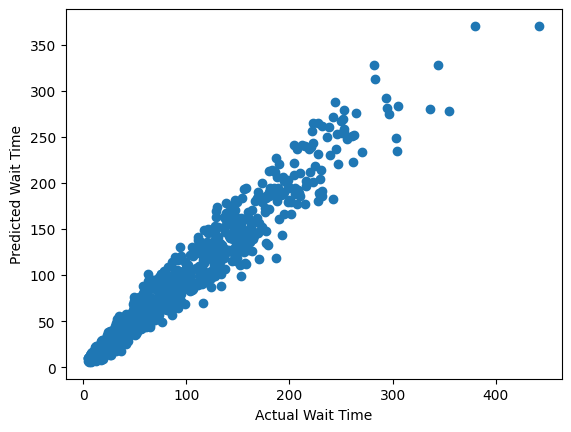

In [112]:
import matplotlib.pyplot as plt
y_pred = pipe.predict(X_test)
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Wait Time")
plt.ylabel("Predicted Wait Time")
plt.show()

In [115]:
loaded_model = joblib.load('wait_time_model.pkl')

predicted_wait = loaded_model.predict(new_patient)

print("Predicted Total Wait Time:",
      round(predicted_wait[0], 2),
      "minutes")

Predicted Total Wait Time: 38.73 minutes
